# GROUP ASSIGNMENT 
Abalone Snail, Machine Learning Case Study
![Abalone Snail Image Sample](./snail.png)

## Importing the Required Libraries

In [1]:
#importing data libraries

# libraries for statistics and data reading 
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error)


## Load the Dataset

In [2]:
df = pd.read_csv("./abalone.data.csv")

# Creating the age column
df["Age"] = df["Rings"] + 1.5

## Data Preview Of the Data

In [3]:
df.sample(10)

,gender,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,Age
2010,I,0.435,0.325,0.120,0.3460,0.1590,0.0840,0.0950,7,8.5
3307,F,0.450,0.325,0.135,0.4380,0.1805,0.1165,0.1100,9,10.5
2198,I,0.270,0.190,0.080,0.0810,0.0265,0.0195,0.0300,6,7.5
1094,I,0.470,0.380,0.125,0.4845,0.2110,0.1075,0.1420,6,7.5
3057,M,0.615,0.490,0.170,1.1450,0.4915,0.2080,0.3430,13,14.5
3379,I,0.295,0.210,0.080,0.1000,0.0380,0.0260,0.0310,8,9.5
476,F,0.465,0.350,0.115,0.4210,0.1565,0.0910,0.1345,9,10.5
2281,I,0.485,0.415,0.140,0.5705,0.2500,0.1340,0.1850,8,9.5
325,I,0.355,0.275,0.090,0.2510,0.0970,0.0530,0.0800,7,8.5
2569,I,0.460,0.345,0.115,0.4215,0.1895,0.1020,0.1110,6,7.5


## Dataset Strucuture

In [4]:
print(f"There are {df.shape}, rows and columns respectfully")

There are (4177, 10), rows and columns respectfully


### Listed Columns inside the data collected

In [5]:
df.columns

Index(['gender', 'Length', 'Diameter', 'Height', 'Whole weight',
       'Shucked weight', 'Viscera weight', 'Shell weight', 'Rings', 'Age'],
      dtype='object')

### Nature of the Data Collected (Data Types)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
 9   Age             4177 non-null   float64
dtypes: float64(8), int64(1), object(1)
memory usage: 326.5+ KB


### Checking for missing Values 

In [7]:
df.isnull().sum()


gender            0
Length            0
Diameter          0
Height            0
Whole weight      0
Shucked weight    0
Viscera weight    0
Shell weight      0
Rings             0
Age               0
dtype: int64

### Statistical Overview of the Data

In [8]:
df.describe()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,Age
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684,11.433684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000,2.500000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000,9.500000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000,10.500000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000,12.500000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000,30.500000


### Feature Engineering

## Finding Correlation

In [9]:
correlation_matrix = df.corr(numeric_only=True)
correlation_matrix

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,Age
Length,1.000000,0.986812,0.827554,0.925261,0.897914,0.903018,0.897706,0.556720,0.556720
Diameter,0.986812,1.000000,0.833684,0.925452,0.893162,0.899724,0.905330,0.574660,0.574660
Height,0.827554,0.833684,1.000000,0.819221,0.774972,0.798319,0.817338,0.557467,0.557467
Whole weight,0.925261,0.925452,0.819221,1.000000,0.969405,0.966375,0.955355,0.540390,0.540390
Shucked weight,0.897914,0.893162,0.774972,0.969405,1.000000,0.931961,0.882617,0.420884,0.420884
Viscera weight,0.903018,0.899724,0.798319,0.966375,0.931961,1.000000,0.907656,0.503819,0.503819
Shell weight,0.897706,0.905330,0.817338,0.955355,0.882617,0.907656,1.000000,0.627574,0.627574
Rings,0.556720,0.574660,0.557467,0.540390,0.420884,0.503819,0.627574,1.000000,1.000000
Age,0.556720,0.574660,0.557467,0.540390,0.420884,0.503819,0.627574,1.000000,1.000000


### Correlation with the Target (Age)

In [10]:
correlation_matrix["Age"].sort_values(ascending=False)

Rings             1.000000
Age               1.000000
Shell weight      0.627574
Diameter          0.574660
Height            0.557467
Length            0.556720
Whole weight      0.540390
Viscera weight    0.503819
Shucked weight    0.420884
Name: Age, dtype: float64

### Correlation with Rings 

In [11]:
correlation_matrix["Rings"].sort_values(ascending=False)

Rings             1.000000
Age               1.000000
Shell weight      0.627574
Diameter          0.574660
Height            0.557467
Length            0.556720
Whole weight      0.540390
Viscera weight    0.503819
Shucked weight    0.420884
Name: Rings, dtype: float64

### Correlation Heatmap

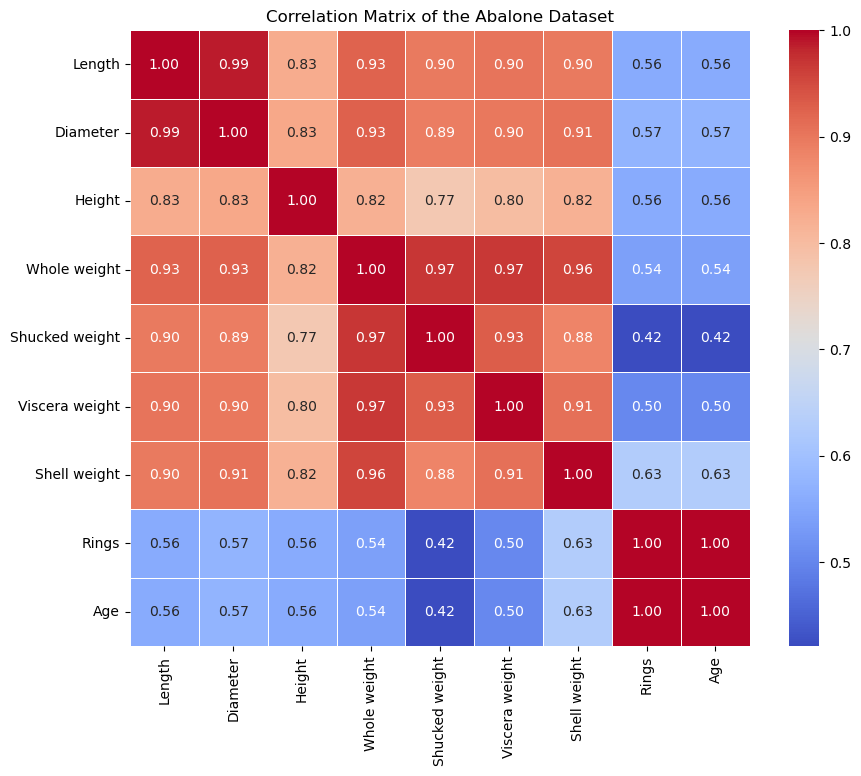

In [12]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of the Abalone Dataset")
plt.show()

### FInding the Outliers

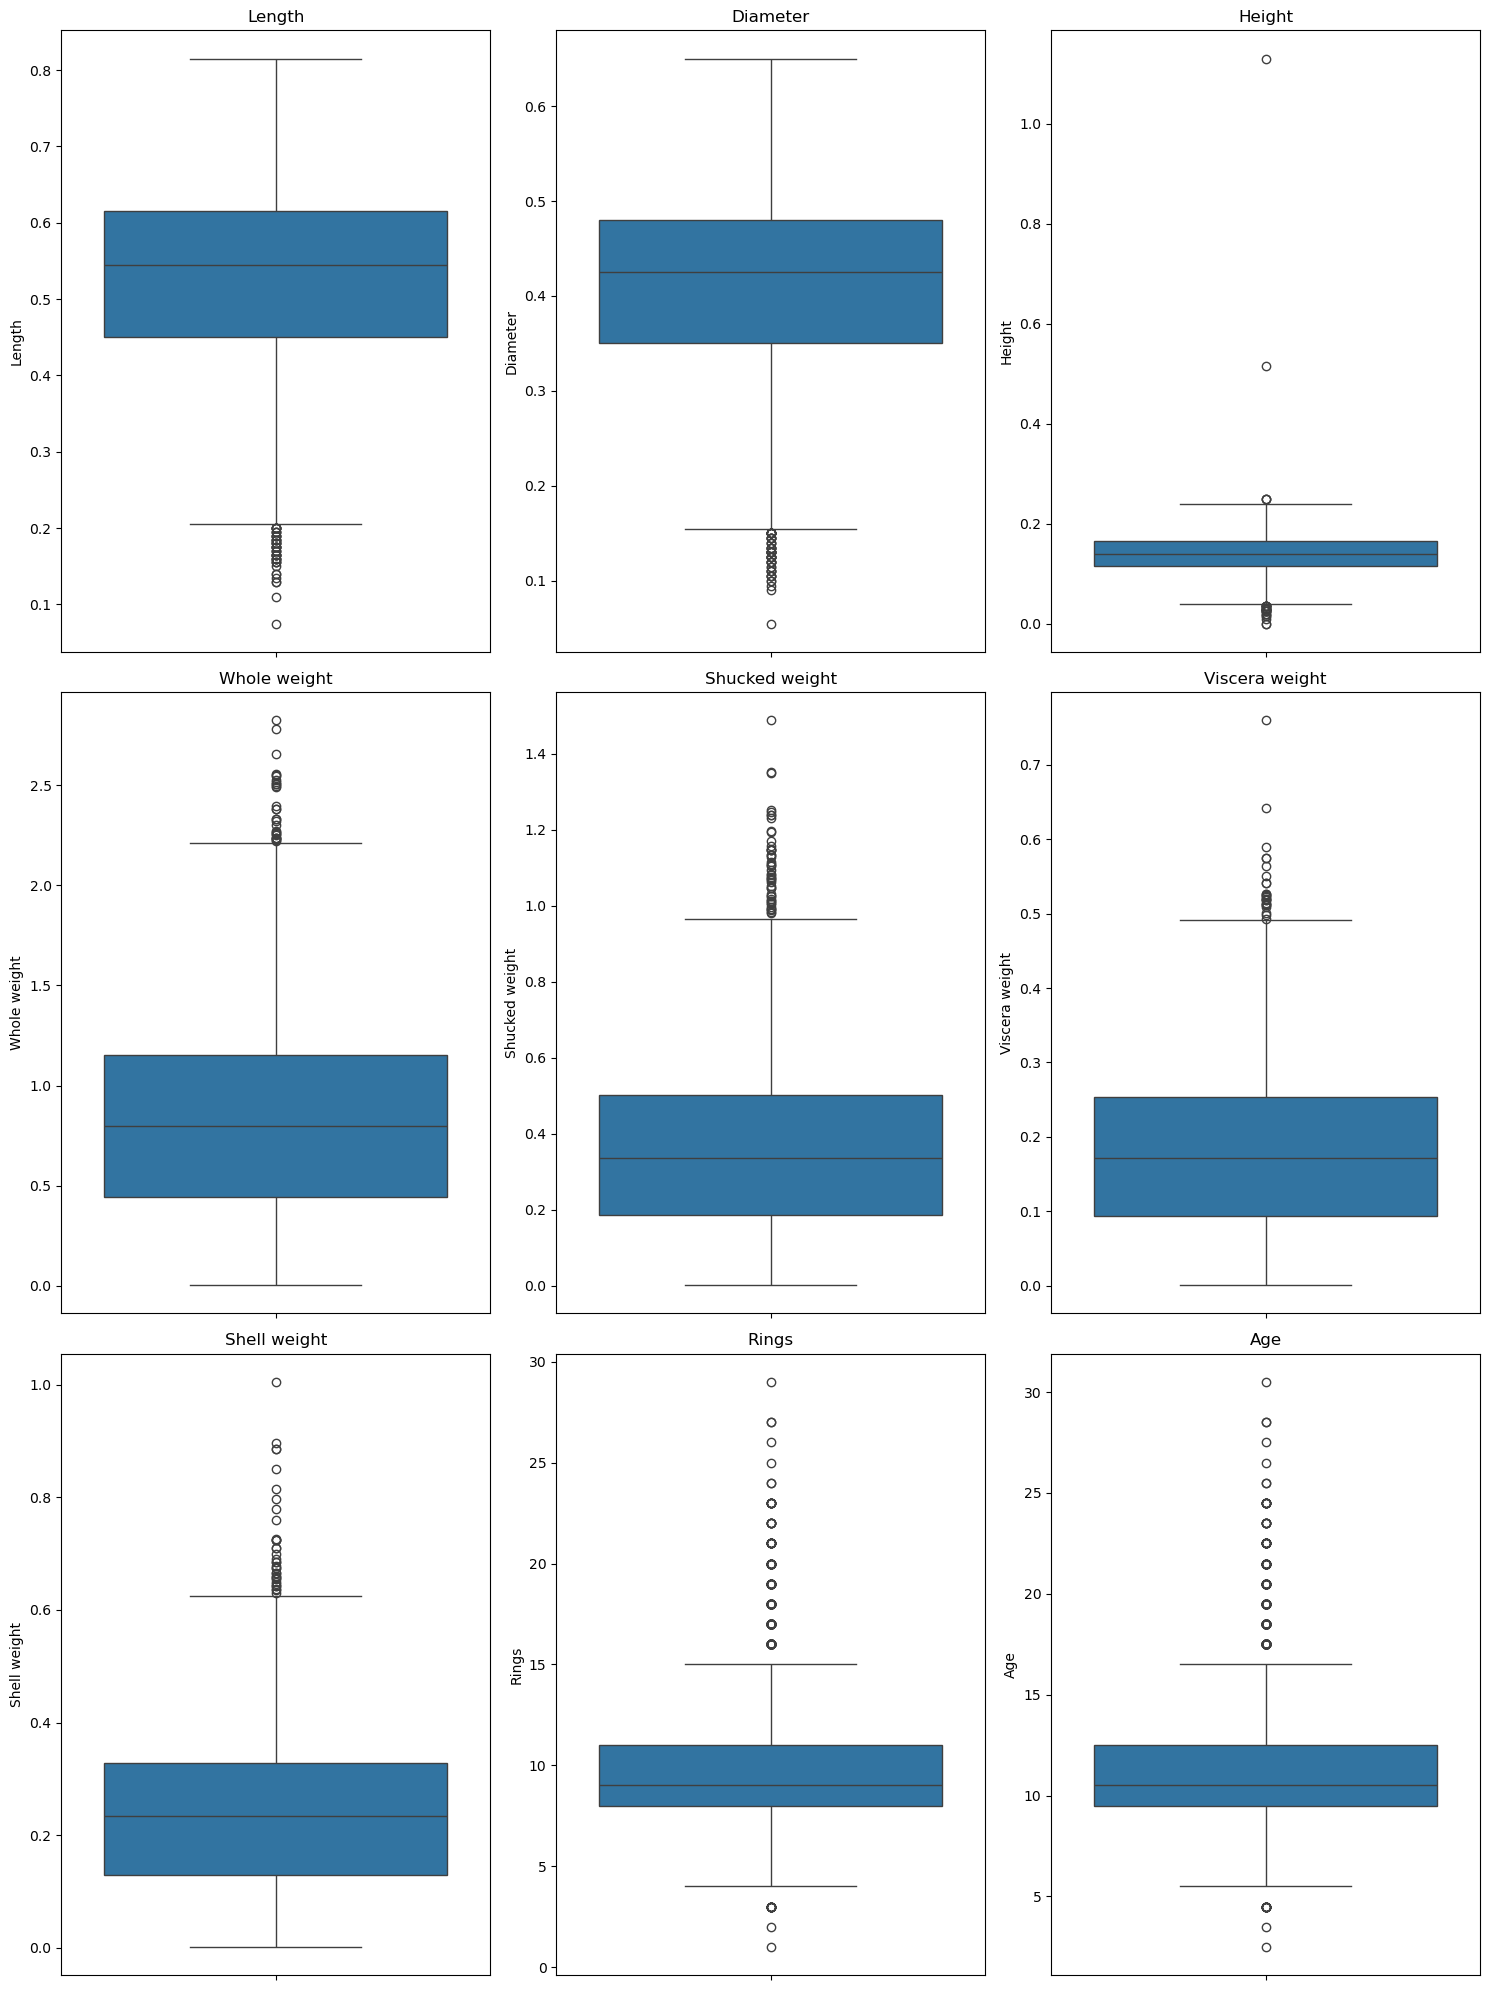

In [13]:
numeric_columns = df.select_dtypes(include="number").columns

plt.figure(figsize=(15, 20))

for i, column in enumerate(numeric_columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

### Data Cleaning and Removing the Outliers using IQR Method 
Where For below is Q1 - 1.5 x IQR 
For Above 
Q3 + 1.5 x IQR

In [14]:
#Selecting the Numberical Columns
numerical_columns = df.select_dtypes(include="number").columns 

#Calculating the Q1, Q2 and IQR
Q1 = df[numerical_columns].quantile(0.25)
Q3 = df[numerical_columns].quantile(0.75)
IQR = Q3 - Q1 


# Removing the Outliers 
df_clean = df[
    ~(
        ((df[numerical_columns] < (Q1 - 1.5 * IQR)) |
         (df[numerical_columns] > (Q3 + 1.5 * IQR)))
    ).any(axis=1)
]

### Comparing the Data Original and The New Data

In [15]:
print("Original Dataset Shape :", df.shape)
print("Cleaned Dataset Shape  :", df_clean.shape)

Original Dataset Shape : (4177, 10)
Cleaned Dataset Shape  : (3781, 10)


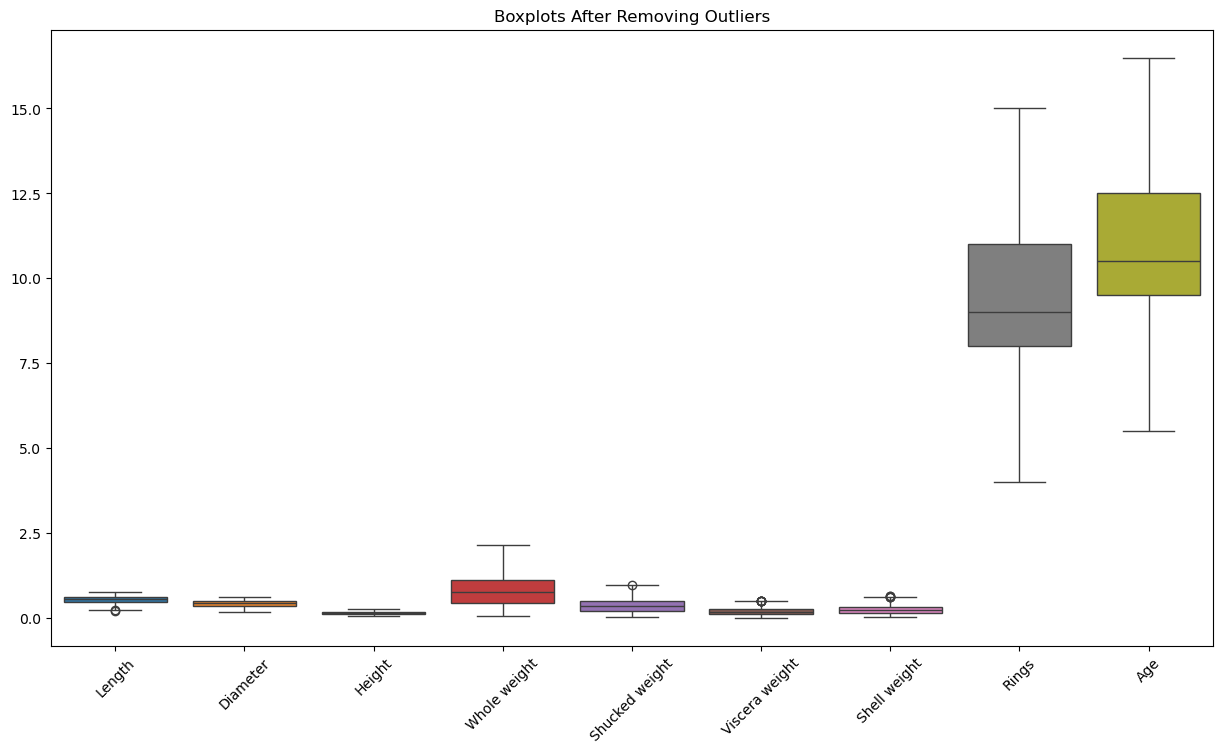

In [16]:
plt.figure(figsize=(15,8))

sns.boxplot(data=df_clean.select_dtypes(include="number"))

plt.title("Boxplots After Removing Outliers")

plt.xticks(rotation=45)

plt.show()

In [17]:
correlation_matrix = df_clean.corr(numeric_only=True)
correlation_matrix["Rings"].sort_values(ascending=False)

Rings             1.000000
Age               1.000000
Shell weight      0.624113
Height            0.615657
Diameter          0.604331
Length            0.587108
Whole weight      0.561207
Viscera weight    0.546232
Shucked weight    0.469503
Name: Rings, dtype: float64

### Old vs New Correlation Matrices

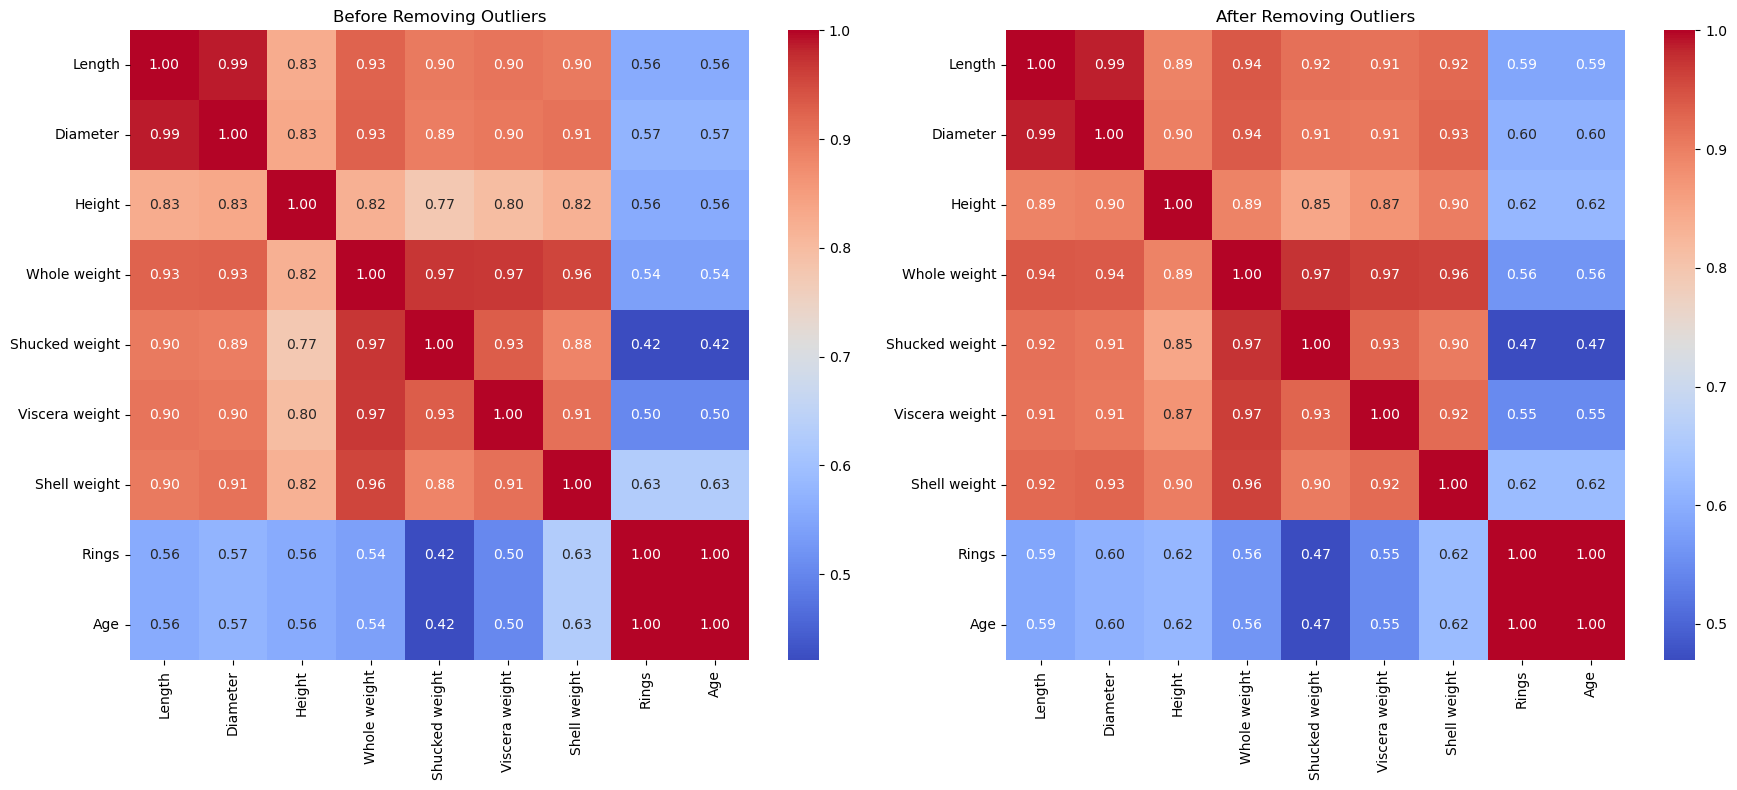

In [18]:
# Correlation matrices
corr_before = df.corr(numeric_only=True)
corr_after = df_clean.corr(numeric_only=True)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Before removing outliers
sns.heatmap(
    corr_before,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    ax=axes[0]
)

axes[0].set_title("Before Removing Outliers")

# After removing outliers
sns.heatmap(
    corr_after,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    ax=axes[1]
)

axes[1].set_title("After Removing Outliers")

plt.tight_layout()
plt.show()

# Feature Selection

In [19]:
# Features (Predictors)
X = df_clean.drop(columns=["Age", "Rings"])

# Target
y = df_clean["Age"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['gender', 'Length', 'Diameter', 'Height', 'Whole weight',
       'Shucked weight', 'Viscera weight', 'Shell weight'],
      dtype='object')

Target:
Age


In [20]:
X.head()

,gender,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055


In [21]:
y.head()

0    16.5
1     8.5
2    10.5
3    11.5
4     8.5
Name: Age, dtype: float64

### Data Preprocessing (For non-numericals: Gender)

In [22]:
categorical_features = ["gender"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ],
    remainder="passthrough"
)

### Split the Dataset

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (3024, 8)
Testing set : (757, 8)


### Verify the Data Split

In [24]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Target  :", y_train.shape)
print("Testing Target   :", y_test.shape)

Training Features: (3024, 8)
Testing Features : (757, 8)
Training Target  : (3024,)
Testing Target   : (757,)


# Model Training

In [25]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
}

trained_models = {}
predictions = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline
    predictions[name] = pipeline.predict(X_test)

    print(f"{name} trained successfully.")

Linear Regression trained successfully.
Decision Tree trained successfully.


Random Forest trained successfully.


# Model Evaluation

In [26]:
results = []

for name, y_pred in predictions.items():

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    results.append({
        "Model": name,
        "R² Score": r2,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE (%)": mape
    })

# Create comparison table
results_df = pd.DataFrame(results)

# Round values for neat presentation
results_df = results_df.round(4)

# Sorting the Best Model
results_df = results_df.sort_values(
    by="R² Score",
    ascending=False
)

results_df

,Model,R² Score,MAE,MSE,RMSE,MAPE (%)
2,Random Forest,0.5319,1.2628,2.606,1.6143,11.7476
0,Linear Regression,0.5312,1.2443,2.610,1.6155,11.6048
1,Decision Tree,0.1212,1.6301,4.893,2.2120,14.9943


# Feature Importance

In [27]:
rf_model = trained_models["Random Forest"].named_steps["model"]

encoded_features = trained_models["Random Forest"]\
    .named_steps["preprocessor"]\
    .get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": encoded_features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
8,remainder__Shell weight,0.510548
6,remainder__Shucked weight,0.134183
5,remainder__Whole weight,0.078815
7,remainder__Viscera weight,0.075876
4,remainder__Height,0.058039
2,remainder__Length,0.053941
3,remainder__Diameter,0.049246
0,cat__gender_I,0.030157
1,cat__gender_M,0.009194


## Plotting Feature Importance

/tmp/ipykernel_165655/1954146019.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


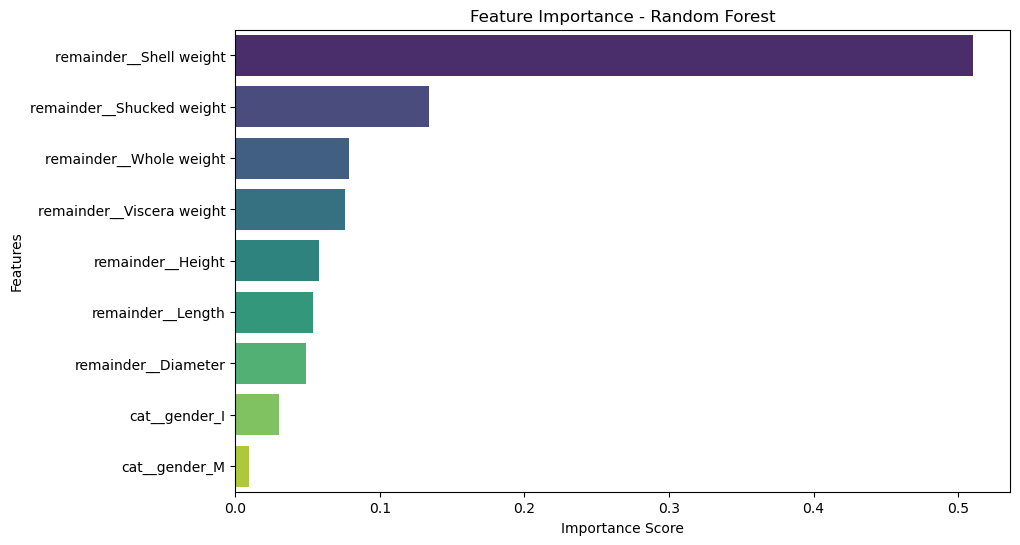

In [28]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

# Saving the Model

In [29]:
import joblib

# Save the best model (Random Forest)
joblib.dump(
    trained_models["Random Forest"],
    "abalone_age_predictor.pkl"
)

print("Model saved successfully!")

Model saved successfully!


# Load Model and Test

In [30]:
loaded_model = joblib.load("abalone_age_predictor.pkl")

new_data = pd.DataFrame({
    "gender": ["M"],
    "Length": [0.55],
    "Diameter": [0.44],
    "Height": [0.15],
    "Whole weight": [0.90],
    "Shucked weight": [0.42],
    "Viscera weight": [0.18],
    "Shell weight": [0.25]
})

predicted_age = loaded_model.predict(new_data)

print(f"Predicted Age: {predicted_age[0]:.2f} years")



Predicted Age: 10.45 years


# Flexible Model Trier

In [31]:
gender = input("Gender (M/F/I): ")

length = float(input("Length: "))
diameter = float(input("Diameter: "))
height = float(input("Height: "))
whole_weight = float(input("Whole Weight: "))
shucked_weight = float(input("Shucked Weight: "))
viscera_weight = float(input("Viscera Weight: "))
shell_weight = float(input("Shell Weight: "))

new_data = pd.DataFrame({
    "gender": [gender],
    "Length": [length],
    "Diameter": [diameter],
    "Height": [height],
    "Whole weight": [whole_weight],
    "Shucked weight": [shucked_weight],
    "Viscera weight": [viscera_weight],
    "Shell weight": [shell_weight]
})

predicted_age = loaded_model.predict(new_data)

print(f"\nPredicted Age: {predicted_age[0]:.2f} years")

ValueError: could not convert string to float: ''